## ARIMA

----

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

In [2]:
df = pd.read_csv('lab_03/data.csv', sep=';')
df.rename(columns={'date1': 'month', 'date2': 'year', 'x2': 'avg_daily_rate'}, inplace=True)
df.drop(columns=['x1', 'x3', 'x4'], inplace=True)
df['avg_daily_rate'] = df['avg_daily_rate'].apply(lambda x: '.'.join(x.split(',')))
df = df[df['avg_daily_rate'] != ' ']
df['avg_daily_rate'] = df['avg_daily_rate'].astype(float)
df['year'] = df['year'].astype(int)

def month2n(month: str):
    monthes = [
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December'
    ]

    return monthes.index(month)


df['month_n'] = df['month'].apply(month2n)
df['timestamp'] = (df['year'] - 1994) * 12 + df['month_n'] + 1
df.head()

,month,year,avg_daily_rate,month_n,timestamp
0,January,1994,104.04,0,1
1,February,1994,102.74,1,2
2,March,1994,105.23,2,3
3,April,1994,113.63,3,4
4,May,1994,120.77,4,5


<Axes: >

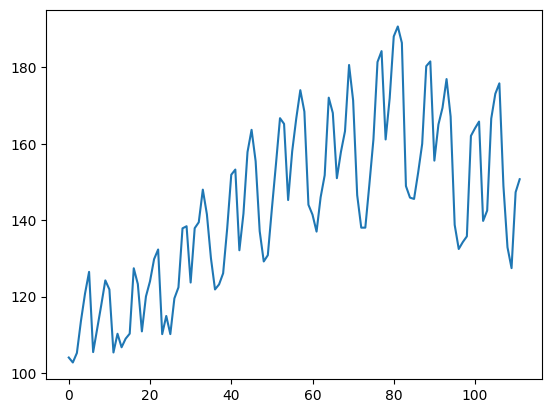

In [3]:
data = df['avg_daily_rate']

data.plot()

### Ряд имеет тренд $\Rightarrow$ d = 1 или 2

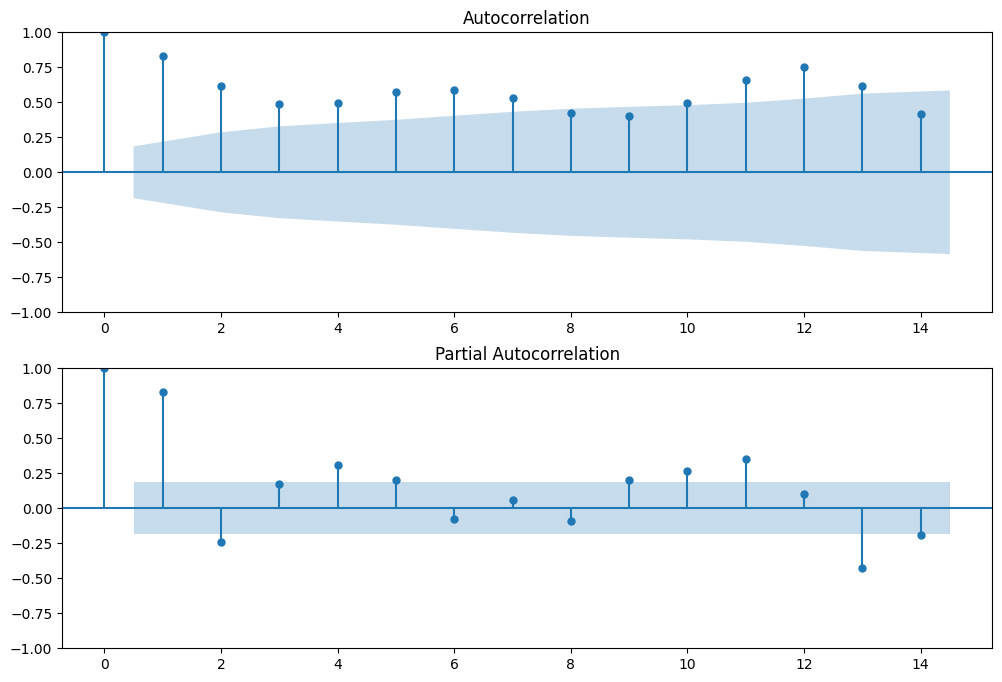

In [4]:
plt.figure(figsize=(12,8))
plt.subplot(211)
plot_acf(data, lags=14, ax=plt.gca())
plt.subplot(212)

plot_pacf(data, method='ywmle', lags=14, ax=plt.gca())
plt.show()

In [51]:
model1 = ARIMA(data, order=(12,1,1))
model1 = model1.fit()

model2 = ARIMA(data, order=(1,1,12))
model2 = model2.fit()

model3 = ARIMA(data, order=(1,2,12))
model3 = model3.fit()

model4 = ARIMA(data, order=(12,2,1))
model4 = model4.fit()

/Users/d.kapanadze/Downloads/Учеба/ИТМО/2 семестр/Анализ данных на python/.venv/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/d.kapanadze/Downloads/Учеба/ИТМО/2 семестр/Анализ данных на python/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/d.kapanadze/Downloads/Учеба/ИТМО/2 семестр/Анализ данных на python/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/d.kapanadze/Downloads/Учеба/ИТМО/2 семестр/Анализ данных на python/.venv/lib/python3.11/site-p

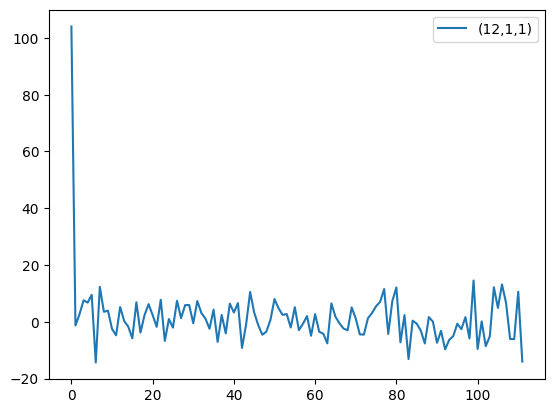

In [52]:
residual = model1.resid
residual.plot(label='(12,1,1)')
plt.legend()

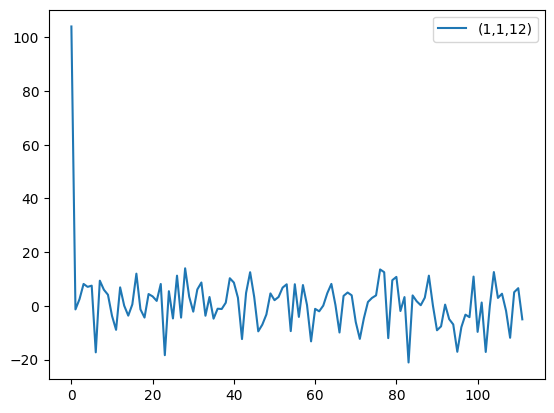

In [56]:
residual = model2.resid
residual.plot(label='(1,1,12)')
plt.legend()

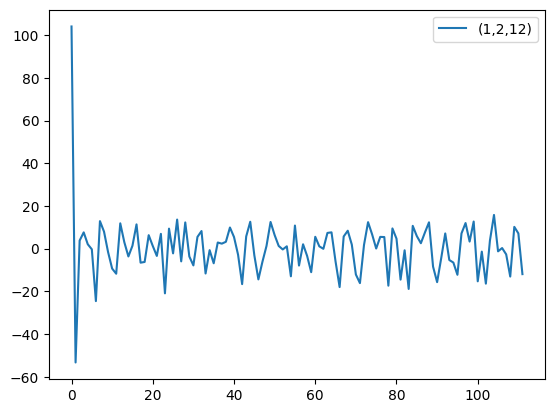

In [57]:
residual = model3.resid
residual.plot(label='(1,2,12)')
plt.legend()

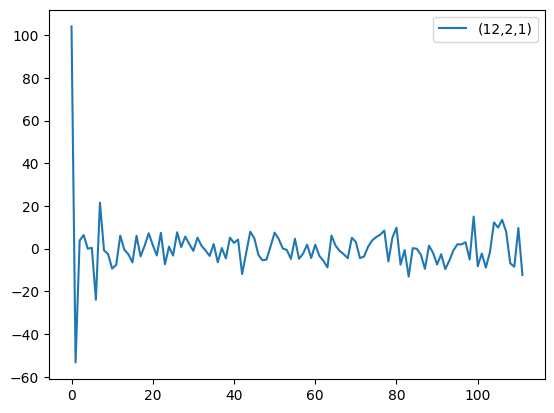

In [58]:
residual = model4.resid
residual.plot(label='(12,2,1)')
plt.legend()

----

### По итогу будем использовать параметры (1,1,12) - лучше всего показывают себя на практике

In [63]:
model = ARIMA(data, order=(1,1,12))
model = model.fit()

/Users/d.kapanadze/Downloads/Учеба/ИТМО/2 семестр/Анализ данных на python/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [64]:
pred = model.predict(1)

for j in range(112, 120):
    pred = pd.concat([pred, model.predict(j)])

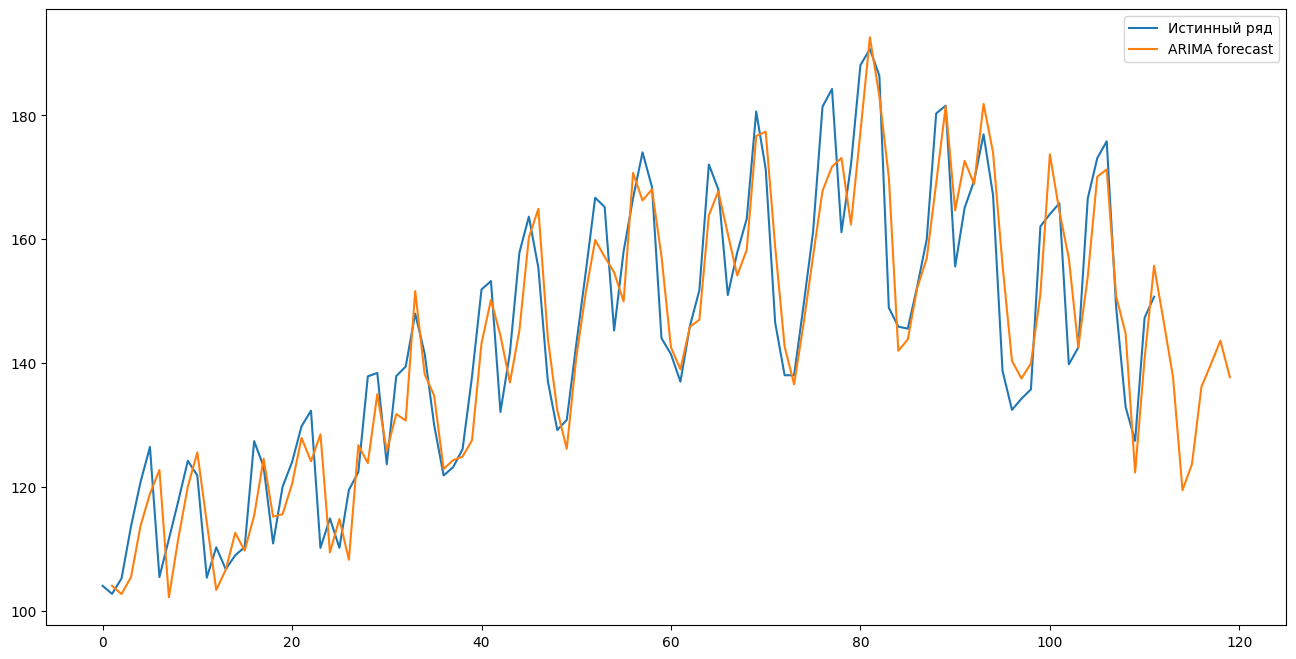

In [79]:
plt.figure(figsize=(16,8))
plt.plot(data, label='Истинный ряд')
plt.plot(pred, label='ARIMA forecast')
plt.legend(loc='best')

In [81]:
from sklearn.metrics import mean_absolute_error

arima_err = mean_absolute_error(data, pred[:112])

forecast_ad = pd.read_csv('sem2_lab4_forecast_ad.csv').drop(columns='Unnamed: 0')
forecast_prod = pd.read_csv('sem2_lab4_forecast_prod.csv').drop(columns='Unnamed: 0')
forecast_decompose = pd.read_csv('sem2_lab3_forecast_decompose.csv').drop(columns='Unnamed: 0')

exp_ad_err = mean_absolute_error(data, forecast_ad[:112])
exp_prod_err = mean_absolute_error(data, forecast_prod[:112])
seasonal_decomp_err = mean_absolute_error(data[5:105], forecast_decompose)



print(f"MAE ARIMA: {arima_err:.2f}")
print(f"MAE exp smoothing, аддитивный тренд : {exp_ad_err:.2f}")
print(f"MAE exp smoothing, мультипликативный тренд: {exp_prod_err:.2f}")
print(f"MAE seasonal decomposition: {seasonal_decomp_err:.2f}")

MAE ARIMA: 5.89
MAE exp smoothing, аддитивный тренд : 3.41
MAE exp smoothing, мультипликативный тренд: 3.41
MAE seasonal decomposition: 4.47


----

### Как видим, ARIMA проигрывает и экспоненциальному сглаживанию, и сезонной декомпозиции